# 01 - Data Inspection

## Setups and Imports

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / 'src').exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / 'src').exists():
    PROJECT_DIR = CURRENT_DIR.parent

SRC_DIR = PROJECT_DIR / 'src'

for dir in [PROJECT_DIR, SRC_DIR]:
    if str(dir) not in sys.path:
        sys.path.append(str(dir))

print(f'Project dir: {PROJECT_DIR}')
print(f'src dir: {SRC_DIR}')

Project dir: c:\Users\ramom\Desktop\pothole-segmentation-system
src dir: c:\Users\ramom\Desktop\pothole-segmentation-system\src


In [2]:
import json, random
import os, shutil
from typing import Iterable
from IPython.display import HTML, Image, display

import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.mask_utils import (
    validate_yolo_segmentation_label,
    generate_mask,
    masks_grid,
    generate_image_overlay,
    validate_mask,
    generate_video_overlay_frames
)
from src.utils.image_io import (
    save_image,
    images_grid,
    save_video_frames
)

In [3]:
DATA_RAW_DIR = PROJECT_DIR / 'data' / 'raw'
DATA_INTERIM_DIR = PROJECT_DIR / 'data' / 'interim'
REPORTS_DIR = PROJECT_DIR / 'reports'

In [4]:
# Copy raw dataset to interim directory
shutil.copytree(DATA_RAW_DIR, DATA_INTERIM_DIR)

WindowsPath('c:/Users/ramom/Desktop/pothole-segmentation-system/data/interim')

## Helper Functions

In [4]:
def validate_yolo_segmentation_label_dir(labels_dir: Path):
    labels_dir = Path(labels_dir)

    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory does not exist: {labels_dir}")

    if not labels_dir.is_dir():
        raise ValueError(f"Expected labels directory, got file: {labels_dir}")

    directory_report = {
        "labels_dir": str(labels_dir),
        "total_files": 0,
        "valid_files": 0,
        "invalid_files": 0,
        "empty_lines": [],
        "invalid_class_ids": [],
        "less_than_6_coordinate_lines": [],
        "odd_coordinate_lines": [],
        "out_of_range_coordinate_lines": [],
    }

    label_paths = sorted(labels_dir.glob("*.txt"))
    directory_report["total_files"] = len(label_paths)

    for label_path in label_paths:
        file_report = validate_yolo_segmentation_label(label_path)

        file_has_issues = False

        for issue_name, issues in file_report.items():
            directory_report[issue_name].extend(issues)

            if len(issues) > 0:
                file_has_issues = True

        if file_has_issues:
            directory_report["invalid_files"] += 1
        else:
            directory_report["valid_files"] += 1

    return directory_report

def print_tree_dirs(directory, prefix=""):
    path = Path(directory)

    # Keep only directories
    dirs = sorted([item for item in path.iterdir() if item.is_dir()])

    for index, item in enumerate(dirs):
        is_last = index == len(dirs) - 1

        connector = "└── " if is_last else "├── "
        print(f"{prefix}{connector}{item.name}")

        new_prefix = prefix + ("    " if is_last else "│   ")
        print_tree_dirs(item, new_prefix)

def validate_mask_dir(images_dir: Path, masks_dir: Path, mask_suffix: str = ".png"):
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)

    if not images_dir.exists():
        raise FileNotFoundError(f"Images directory does not exist: {images_dir}")

    if not masks_dir.exists():
        raise FileNotFoundError(f"Masks directory does not exist: {masks_dir}")

    if not images_dir.is_dir():
        raise ValueError(f"Expected images directory, got file: {images_dir}")

    if not masks_dir.is_dir():
        raise ValueError(f"Expected masks directory, got file: {masks_dir}")

    directory_report = {
        "images_dir": str(images_dir),
        "masks_dir": str(masks_dir),
        "total_images": 0,
        "valid_masks": 0,
        "invalid_masks": 0,
        "missing_masks": [],
        "unreadable_masks": [],
        "unreadable_images": [],
        "rgb_or_multichannel_masks": [],
        "size_mismatches": [],
        "not_binary_masks": [],
        "no_zero_background_masks": [],
        "extra_masks": [],
    }

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_paths = sorted([
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in image_extensions
    ])

    directory_report["total_images"] = len(image_paths)

    for image_path in image_paths:
        mask_path = masks_dir / f"{image_path.stem}{mask_suffix}"

        file_report = validate_mask(mask_path, image_path)

        file_has_issues = False

        for issue_name, issues in file_report.items():
            directory_report[issue_name].extend(issues)

            if len(issues) > 0:
                file_has_issues = True

        if file_has_issues:
            directory_report["invalid_masks"] += 1
        else:
            directory_report["valid_masks"] += 1

    image_stems = {path.stem for path in image_paths}

    for mask_path in sorted(masks_dir.glob(f"*{mask_suffix}")):
        if mask_path.stem not in image_stems:
            directory_report["extra_masks"].append(str(mask_path))

    return directory_report

def _resize_frame(frame: np.ndarray, width: int) -> np.ndarray:
    '''
    Resize frame while preserving aspect ratio.
    '''
    h, w = frame.shape[:2]
    new_height = int(h * (width / w))
    return cv2.resize(frame, (width, new_height))

def _make_grid(frames: list[np.ndarray], columns: int, width: int) -> np.ndarray:
    '''
    Combine multiple frames into one grid frame.
    '''

    resized_frames = []

    for frame in frames:
        frame = _resize_frame(frame, width)
        resized_frames.append(frame)

    max_height = max(frame.shape[0] for frame in resized_frames)

    padded_frames = []

    for frame in resized_frames:
        h, w = frame.shape[:2]

        if h < max_height:
            padding = np.zeros((max_height - h, w, 3), dtype=np.uint8)
            frame = np.vstack([frame, padding])

        padded_frames.append(frame)

    rows = []

    for i in range(0, len(padded_frames), columns):
        row_frames = padded_frames[i:i + columns]

        while len(row_frames) < columns:
            blank = np.zeros_like(padded_frames[0])
            row_frames.append(blank)

        rows.append(np.hstack(row_frames))

    return np.vstack(rows)

def show_video_grid_cv2(video_paths, columns=3, width=300, fps=None):
    '''
    Display multiple videos in a grid inside Jupyter using OpenCV frame decoding.
    This does not require browser-compatible video codecs.
    '''

    video_paths = [Path(path) for path in video_paths]

    captures = [cv2.VideoCapture(str(path)) for path in video_paths]

    for path, cap in zip(video_paths, captures):
        if not cap.isOpened():
            raise ValueError(f'Could not open video: {path}')

    if fps is None:
        fps_values = [cap.get(cv2.CAP_PROP_FPS) for cap in captures]
        fps_values = [value for value in fps_values if value and value > 0]
        fps = fps_values[0] if fps_values else 30

    delay = 1 / fps

    display_handle = None

    try:
        while True:
            frames = []
            active = False

            for path, cap in zip(video_paths, captures):
                success, frame = cap.read()

                if success:
                    active = True

                    cv2.putText(
                        frame,
                        path.name,
                        (10, 25),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (255, 255, 255),
                        2
                    )

                    frames.append(frame)
                else:
                    # Blank frame after this video ends
                    frames.append(np.zeros((width, width, 3), dtype=np.uint8))

            if not active:
                break

            grid_frame = _make_grid(frames, columns=columns, width=width)

            success, encoded = cv2.imencode('.jpg', grid_frame)

            if not success:
                raise RuntimeError('Failed to encode frame for display')

            image = Image(data=encoded.tobytes())

            if display_handle is None:
                display_handle = display(image, display_id=True)
            else:
                display_handle.update(image)

            time.sleep(delay)

    finally:
        for cap in captures:
            cap.release()



## 1. pothole-dataset-1

In [5]:
dataset_1_dir = DATA_INTERIM_DIR / 'pothole-dataset-1'
reports_dir = REPORTS_DIR / 'data_review' / 'pothole-dataset-1'
print(dataset_1_dir.exists())
print(reports_dir.exists())

True
True


### 1.1 Inspect Directory Structure

In [6]:
print_tree_dirs(dataset_1_dir)

├── full_images
├── full_labels
├── full_masks
├── full_overlays
├── train
│   ├── images
│   └── labels
└── valid
    ├── images
    ├── labels
    └── masks


### 1.2 Check Image-Label Matching

In [7]:
for split in ['train', 'valid']:
    images_dir = dataset_1_dir / split / 'images'
    labels_dir = dataset_1_dir / split / 'labels'

    print(f'Number of images in {images_dir}: {len(os.listdir(images_dir))}')
    print(f'Number of labels in {labels_dir}: {len(os.listdir(labels_dir))}')

    for image_path in images_dir.iterdir():
        label_path = labels_dir / (image_path.stem + '.txt')

        if not label_path.exists():
            print(f'{label_path} is missing')

    print('=' * 100)

Number of images in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-1\train\images: 1590
Number of labels in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-1\train\labels: 1590
Number of images in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-1\valid\images: 381
Number of labels in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-1\valid\labels: 381


### 1.3 Label Files Sanity Check

In [8]:
issues = validate_yolo_segmentation_label_dir(dataset_1_dir / 'train' / 'labels')

with open(reports_dir / 'labels_validation.json', 'w', encoding='utf-8') as f:
    json.dump(issues, f, indent=4)

issues

{'labels_dir': 'c:\\Users\\ramom\\Desktop\\pothole-segmentation-system\\data\\interim\\pothole-dataset-1\\train\\labels',
 'total_files': 1590,
 'valid_files': 1590,
 'invalid_files': 0,
 'empty_lines': [],
 'invalid_class_ids': [],
 'less_than_6_coordinate_lines': [],
 'odd_coordinate_lines': [],
 'out_of_range_coordinate_lines': []}

### 1.4 Flatten Dataset

In [9]:
full_images_dir = dataset_1_dir / 'full_images'
full_labels_dir = dataset_1_dir / 'full_labels'

full_images_dir.mkdir(exist_ok=True)
full_labels_dir.mkdir(exist_ok=True)

for split in ['train', 'valid']:
    images_dir = dataset_1_dir / split / 'images'
    labels_dir = dataset_1_dir / split / 'labels'

    for image_path in images_dir.iterdir():
        shutil.copy(image_path, full_images_dir / (f'pothole_dataset_1_{split}_' + image_path.name))
    
    for label_path in labels_dir.iterdir():
        shutil.copy(label_path, full_labels_dir / (f'pothole_dataset_1_{split}_' + label_path.name))

print(len(os.listdir(full_images_dir)))
print(len(os.listdir(full_labels_dir)))

1971
1971


### 1.5 Generate Masks

In [10]:
images_dir = dataset_1_dir / 'full_images'
labels_dir = dataset_1_dir / 'full_labels'

masks_dir = dataset_1_dir / 'full_masks'
masks_dir.mkdir(exist_ok=True)

for image_path in images_dir.iterdir():
    label_path = labels_dir / (image_path.stem + '.txt')

    mask = generate_mask(image_path, label_path)

    save_image(mask, masks_dir, image_path.stem + '.png')

print(len(os.listdir(masks_dir)))

1971


### 1.6 Masks Inspection

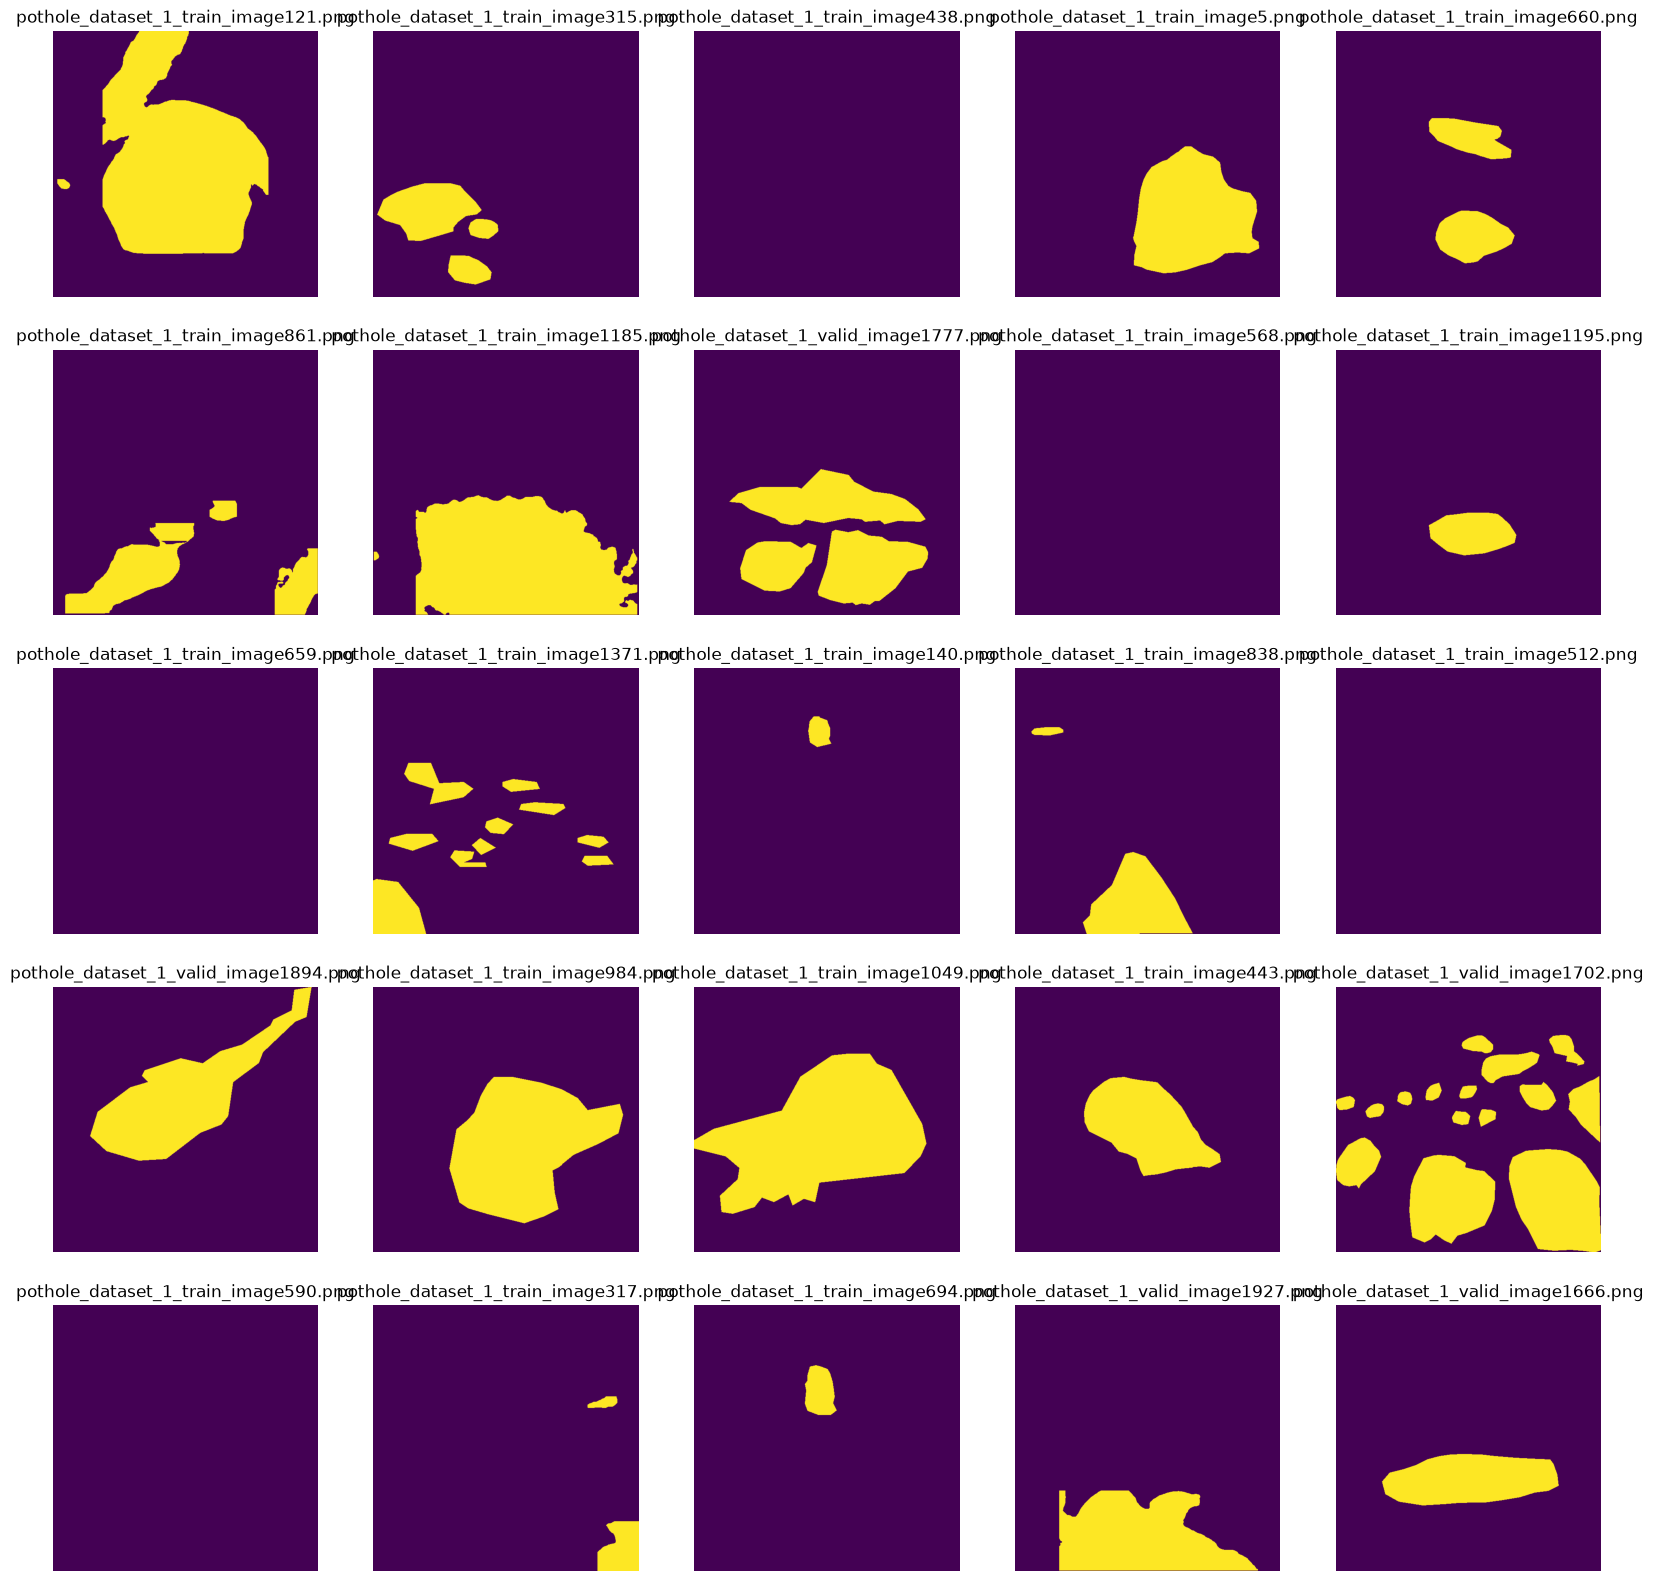

In [11]:
masks_grid(list(masks_dir.iterdir()))

### 1.7 Generate Overlays

In [12]:
overlays_dir = dataset_1_dir / 'full_overlays'
overlays_dir.mkdir(exist_ok=True)

for image_path in images_dir.iterdir():
    mask_path = masks_dir / (image_path.stem + '.png')

    overlay = generate_image_overlay(image_path, mask_path)

    save_image(overlay, overlays_dir, image_path.stem + '.png')

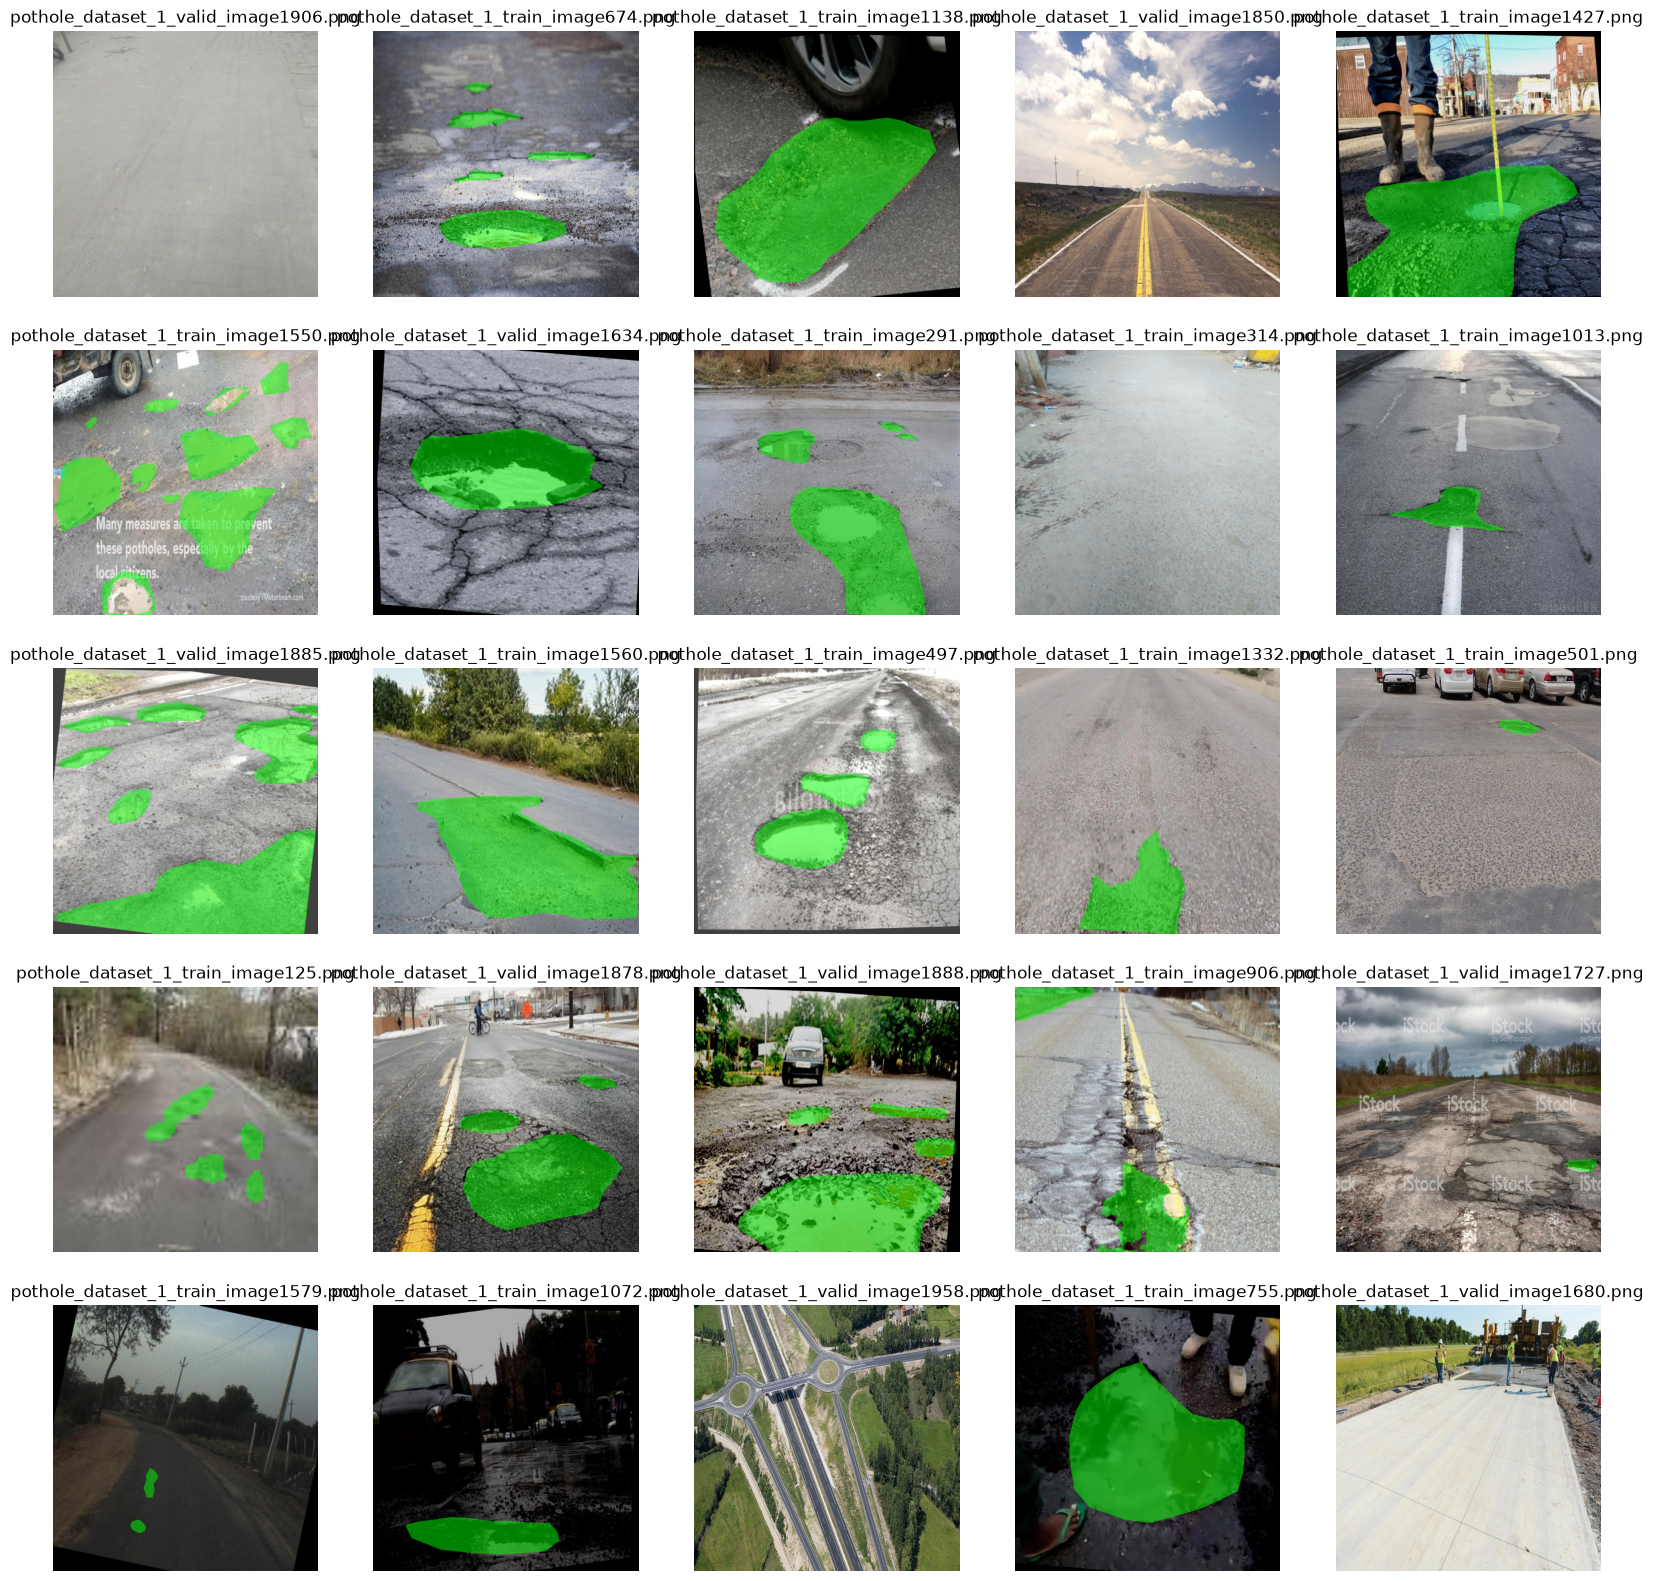

In [13]:
images_grid(list(overlays_dir.iterdir()))

## 2. pothole-dataset-2

In [14]:
dataset_2_dir = DATA_INTERIM_DIR / 'pothole-dataset-2'
reports_dir = REPORTS_DIR / 'data_review' /'pothole-dataset-2'
print(dataset_2_dir.exists())
print(reports_dir.exists())

True
True


### 2.1 Inspect Directory Structure

In [15]:
print_tree_dirs(dataset_2_dir)

├── images
├── masks
└── overlays


In [16]:
images_dir = dataset_2_dir / 'images'
masks_dir = dataset_2_dir  / 'masks'

print(f'Number of images in {images_dir}: {len(os.listdir(images_dir))}')
print(f'Number of masks in {labels_dir}: {len(os.listdir(masks_dir))}')

Number of images in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-2\images: 1000
Number of masks in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-1\full_labels: 700


### 2.2 Rename Files

In [17]:
for image_path in images_dir.iterdir():
    os.rename(image_path, images_dir / (f'pothole_dataset_2_' + image_path.name))

for mask_path in masks_dir.iterdir():
    os.rename(mask_path, masks_dir / (f'pothole_dataset_2_' + mask_path.name))

### 2.2 Check Image-Mask Matching

In [18]:
issues = validate_mask_dir(
    images_dir=dataset_2_dir / "images",
    masks_dir=dataset_2_dir / "masks",
    mask_suffix=".png",
)

with open(reports_dir / "masks_validation.json", "w", encoding="utf-8") as f:
    json.dump(issues, f, indent=4)

### 2.3 Masks Inspection

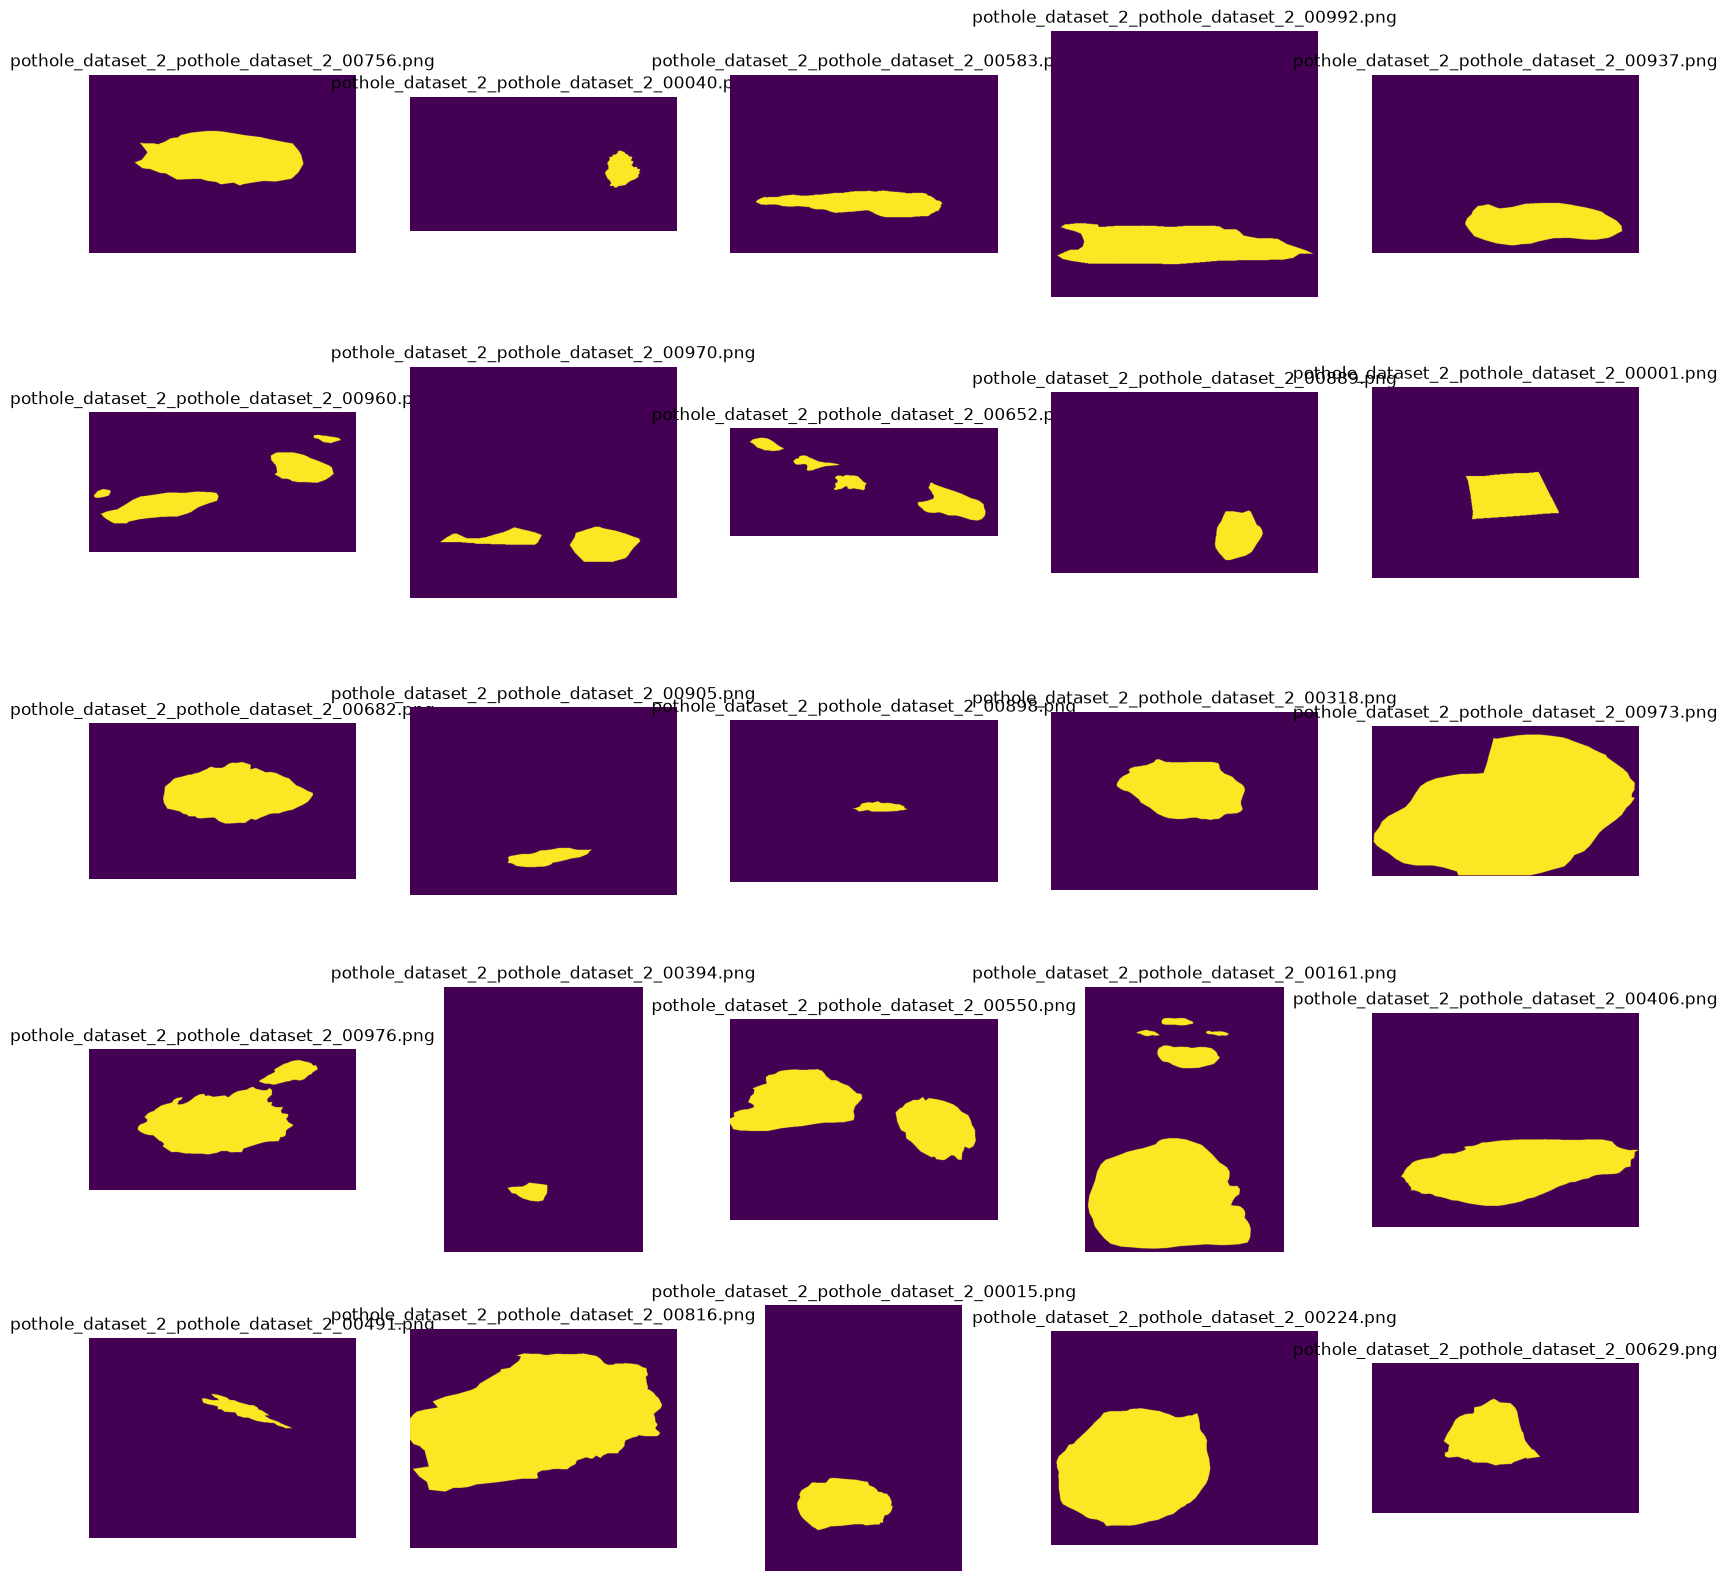

In [19]:
masks_grid(list(masks_dir.iterdir()))

### 2.4 Generate Overlays

In [20]:
overlays_dir = dataset_2_dir / 'overlays'
overlays_dir.mkdir(exist_ok=True)

for image_path in images_dir.iterdir():
    mask_path = masks_dir / (image_path.stem + '.png')

    if not mask_path.exists():
        continue

    overlay = generate_image_overlay(image_path, mask_path)

    save_image(overlay, overlays_dir, image_path.stem + '.png')

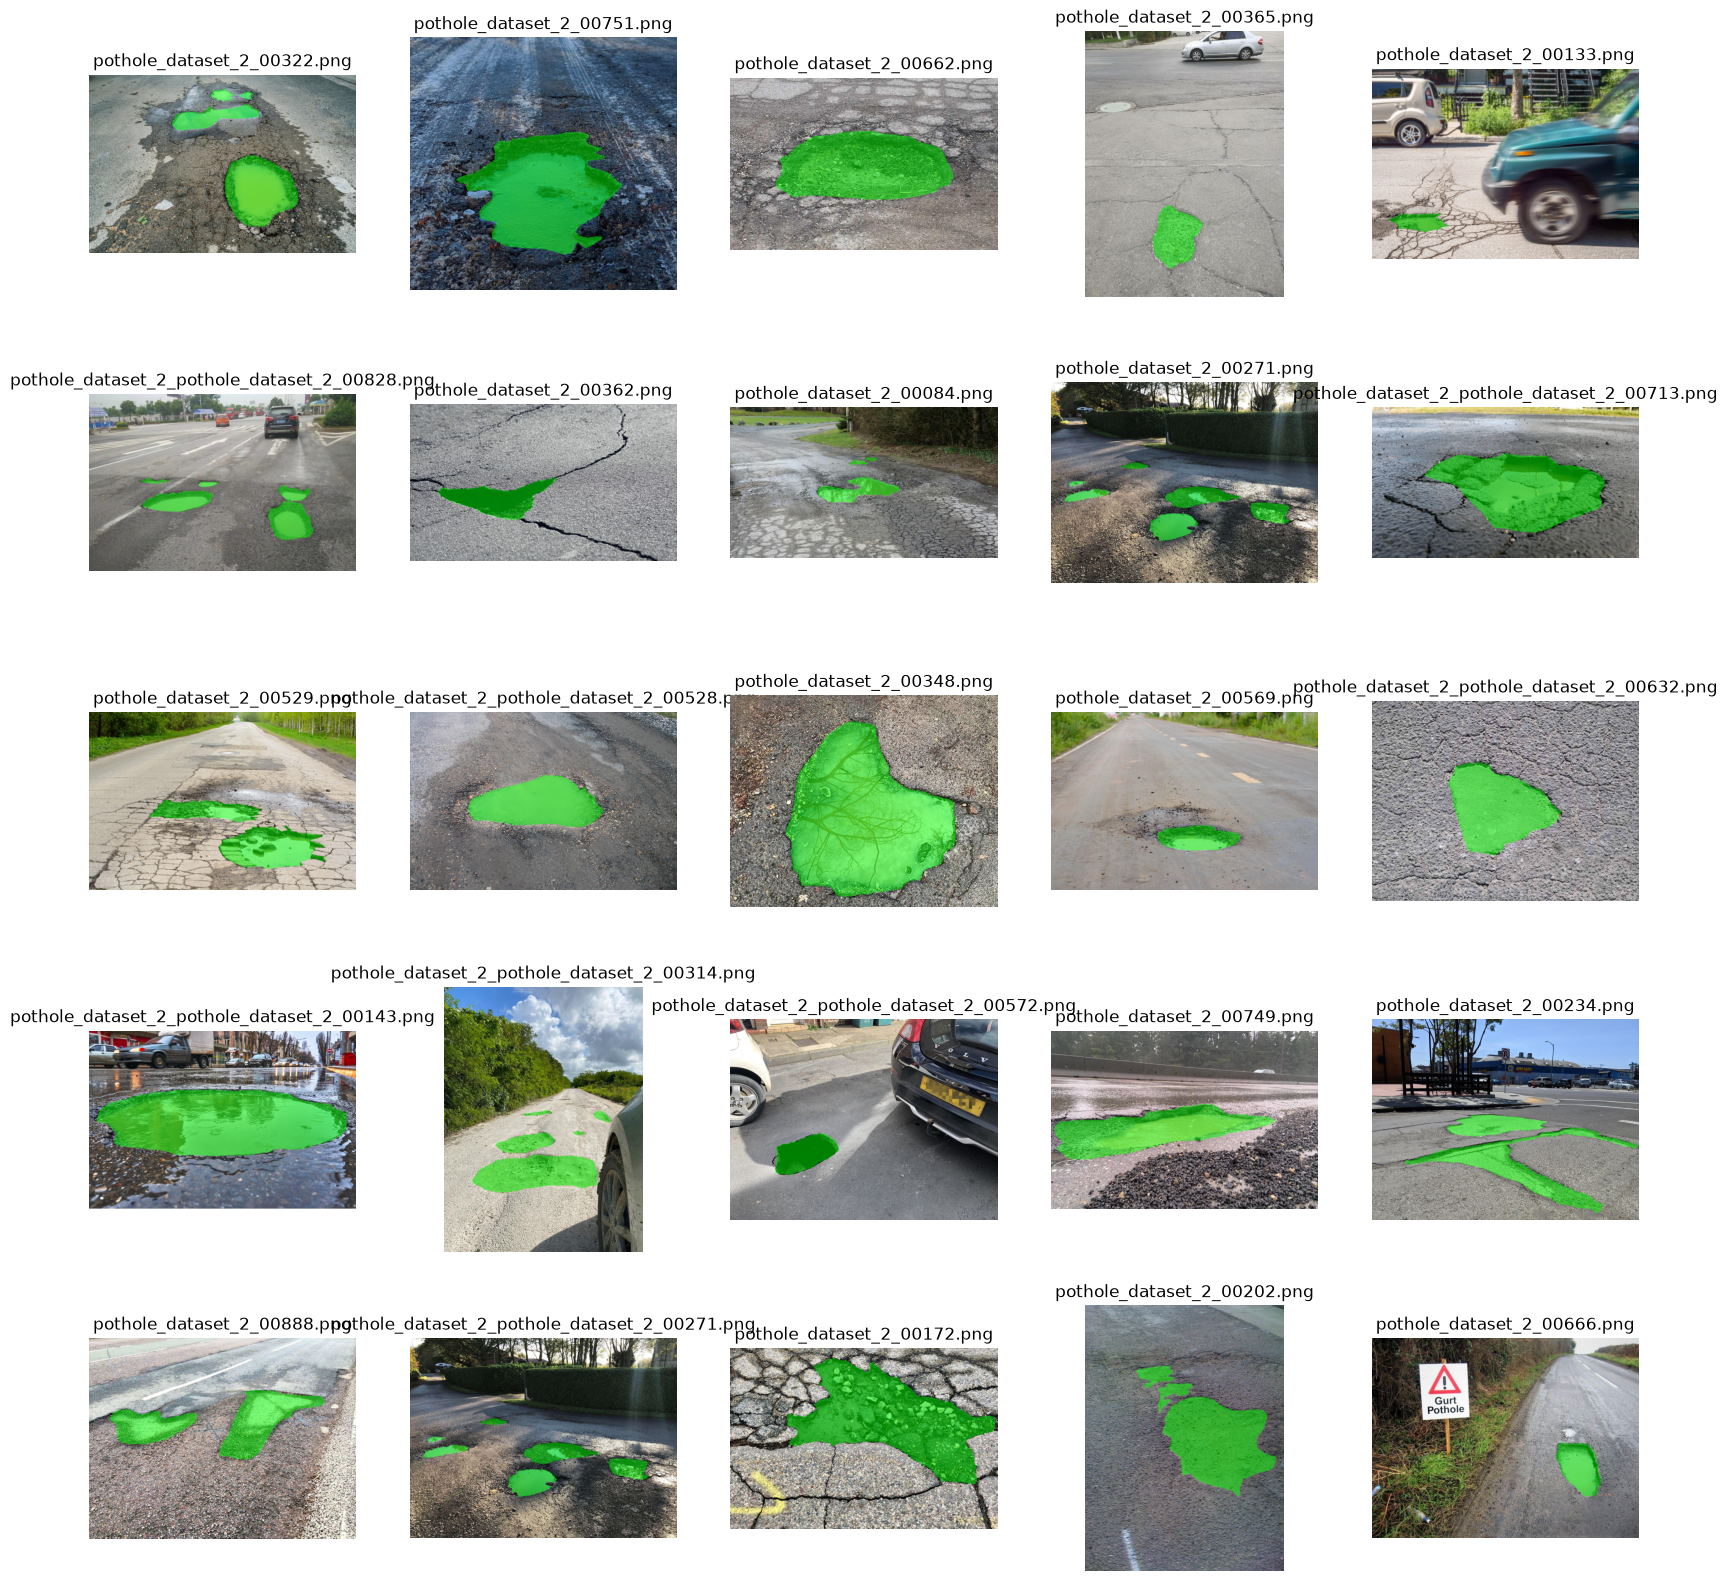

In [21]:
images_grid(list(overlays_dir.iterdir()))

## 3. pothole-dataset-3

In [22]:
dataset_3_dir = DATA_INTERIM_DIR / 'pothole-dataset-3'
reports_dir = REPORTS_DIR / 'data_review' / 'pothole-dataset-3'
print(dataset_3_dir.exists())
print(reports_dir.exists())

True
True


### 3.1 Inspect Directory Structure

In [23]:
print_tree_dirs(dataset_3_dir)

├── test
│   ├── mask_videos
│   └── videos
├── train
│   ├── mask_videos
│   └── videos
└── val
    ├── mask_videos
    └── videos


In [24]:
for split in ['train', 'val', 'test']:
    videos_dir = dataset_3_dir / split / 'videos'
    masks_dir = dataset_3_dir / split / 'mask_videos'

    print(f'Number of videos in {videos_dir}: {len(os.listdir(videos_dir))}')
    print(f'Number of masks in {masks_dir}: {len(os.listdir(masks_dir))}')

    for video_path in videos_dir.iterdir():
        mask_path = masks_dir / (video_path.name)

        if not mask_path.exists():
            print(f'{mask_path} is missing')

    print('=' * 100)

Number of videos in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\train\videos: 372
Number of masks in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\train\mask_videos: 372
Number of videos in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\val\videos: 124
Number of masks in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\val\mask_videos: 124
Number of videos in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\test\videos: 123
Number of masks in c:\Users\ramom\Desktop\pothole-segmentation-system\data\interim\pothole-dataset-3\test\mask_videos: 123


### 3.2 Mask Inspection

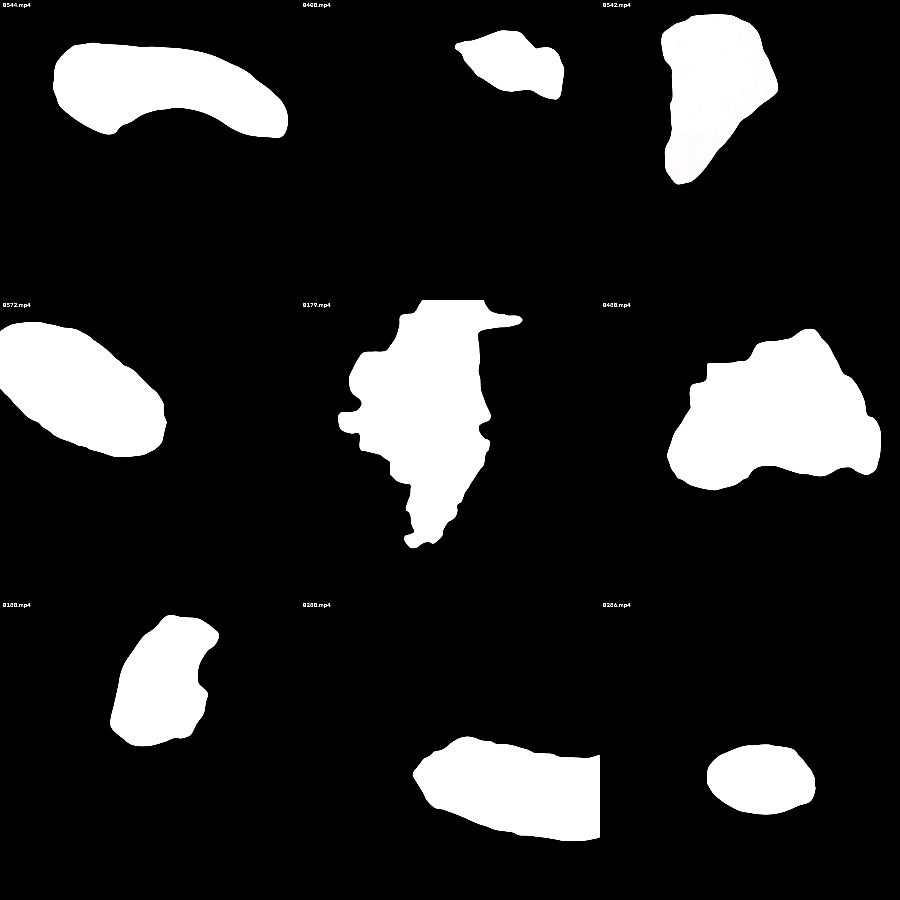

In [25]:
video_paths = []

for split in ['train', 'val', 'test']:
    masks_dir = dataset_3_dir / split / 'mask_videos'
    video_paths.extend(random.sample(list(masks_dir.iterdir()), k=3))

show_video_grid_cv2(
    video_paths=video_paths,
    columns=3,
    width=300
)

### 3.4 Generate Overlays

In [31]:
for split in ['train', 'val', 'test']:
    videos_dir = dataset_3_dir / split / 'videos'
    masks_dir = dataset_3_dir / split / 'mask_videos'

    overlays_dir = dataset_3_dir / split / 'overlay_videos'
    
    os.makedirs(overlays_dir, exist_ok=True)

    for video_path in videos_dir.iterdir():
        mask_path = masks_dir / video_path.name

        frames = generate_video_overlay_frames(
            video_path, 
            mask_path,
        )

        save_video_frames(
            frames,
            overlays_dir,
            video_path.name,
            fps=30
        )

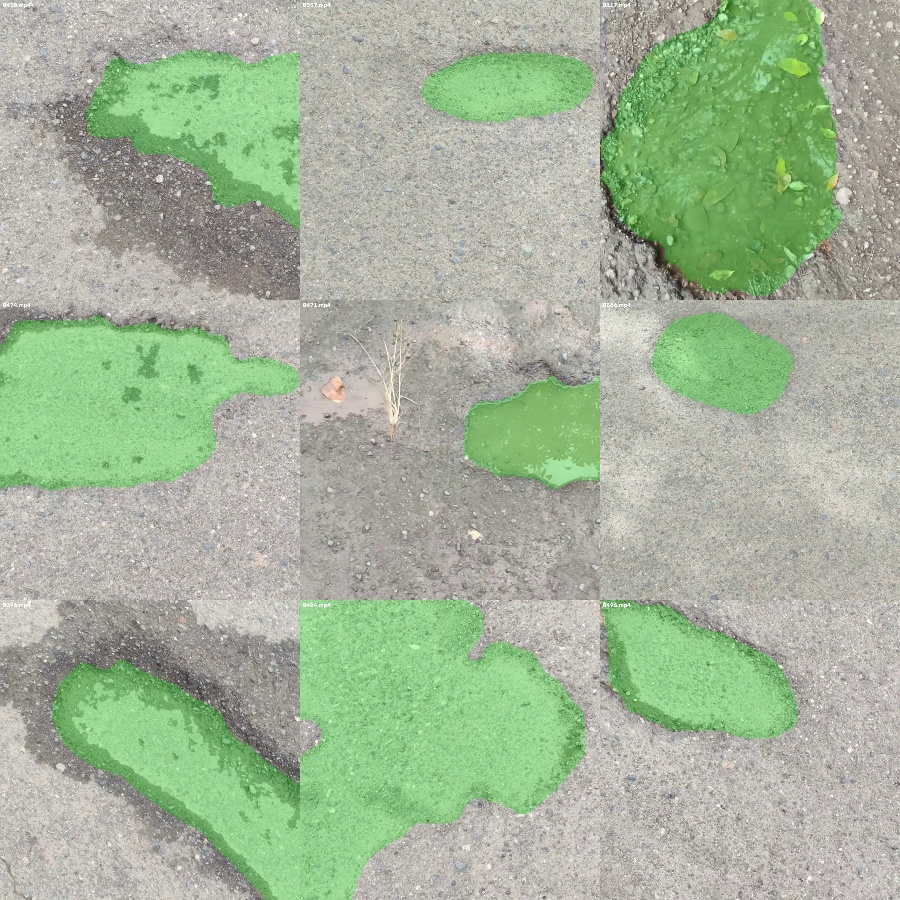

In [32]:
video_paths = []

for split in ['train', 'val', 'test']:
    overlays_dir = dataset_3_dir / split / 'overlay_videos'
    video_paths.extend(random.sample(list(overlays_dir.iterdir()), k=3))

show_video_grid_cv2(
    video_paths=video_paths,
    columns=3,
    width=300
)